<a href="https://colab.research.google.com/github/zelk-oss/Complex-Networks/blob/main/cours2023/gaussian_vs_turbulent_fow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install powerbox

In [2]:
import powerbox as pbox

In [3]:
import numpy as np
import scipy.stats as stats

import PIL
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.size'] = 18

# Topic: non gaussianity of turbulent flow

Principle:
  - take a 2D tubulent flow image
  - compute its power spectrum P(k) via FFT
  - generate a gaussien field with the same P(k)

# Load the image of turbulent flow

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
import os
os.chdir("/content/drive/My Drive/Data4CoursSMallat")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Data4CoursSMallat'

In [9]:
ls

drive/  sample_data/  turbulence.png


In [87]:
imagePIL = Image.open('turbulence.png')
image_o = np.array(Image.open('turbulence.png').convert('L'))

In [78]:
h,w = image_o.shape # heightxwidth
print(h,w)
n = min(h,w)
d = np.log2(n) # max number of scales
print(d, np.floor(d))
npix = int(2**np.floor(d))
image_o = image_o[:npix,:npix]   # simple restriction to power 2 (FFT)
# in this case it was already a power of 2 but we make it if it wasn't

600 447
8.804131021183318 8.0


In [79]:
npix

256

In [80]:
print(image_o.min(), image_o.max(), image_o.mean())
image = image_o/npix**3 # normalisation
print(image.min(), image.max(), image.mean())

1 253 87.4267578125
5.960464477539063e-08 1.5079975128173828e-05 5.21104084327817e-06


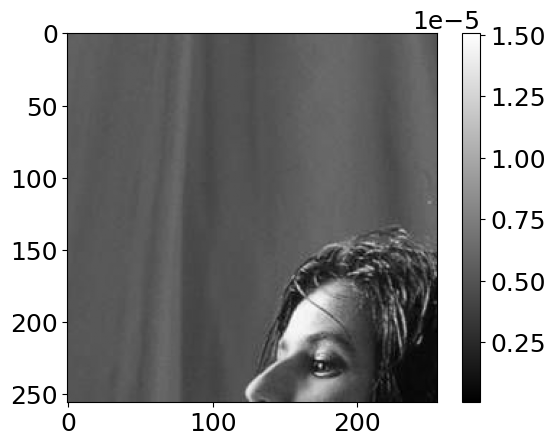

In [81]:
plt.imshow(image, plt.cm.gray), plt.colorbar();

# Compute image power spectrum

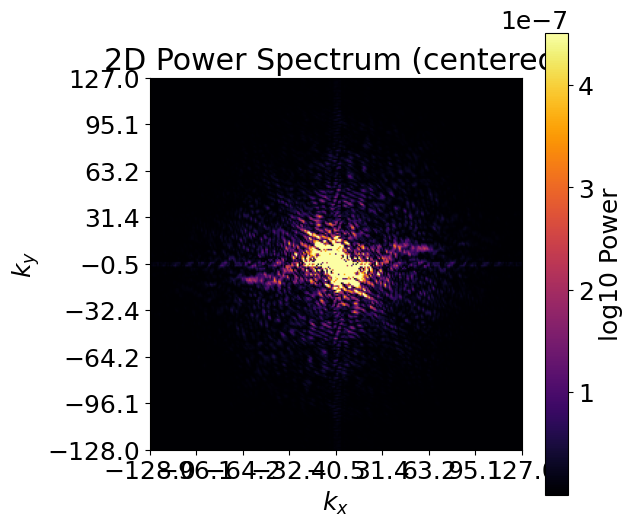

In [84]:
fourier_image = np.fft.fft2(image) # fourier transform
fourier_amplitudes = np.abs(fourier_image)**2 # power spectrum in 2D

# plotting the power spectrum
power2D_shifted = np.fft.fftshift(fourier_amplitudes)
kfreq = np.fft.fftfreq(npix) * npix # frequencies
kshift = np.fft.fftshift(kfreq)

plt.figure(figsize=(6, 6))
# we clip the huge center value so that we can see structure
clipped = np.clip(power2D_shifted, 0, np.percentile(power2D_shifted, 99))
plt.imshow(np.log10(clipped + 1), cmap='inferno', extent=[kshift[0], kshift[-1], kshift[0], kshift[-1]])
plt.colorbar(label='log10 Power')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("2D Power Spectrum (centered)")
ticks = np.linspace(kshift[0], kshift[-1], 9)
plt.xticks(ticks)
plt.yticks(ticks)
plt.show()

# We need a 1D representation for the Power Spectrum: radial averaging

In [85]:
kfreq2D = np.meshgrid(kfreq, kfreq) # frequencies on the grid
##print(np.shape(kfreq2D))
#print(np.max(kfreq2D), np.min(kfreq2D))
knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

knrm = knrm.flatten()
fourier_amplitudes = fourier_amplitudes.flatten()

kbins = np.arange(0.5, npix//2+1, 1.)
kvals = 0.5 * (kbins[1:] + kbins[:-1])
# compute the 1D radially averaged power spectrum
# P(k) = <|F(kx,ky)|^2>_{annulus at |k|=0}
Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                     statistic = "mean",
                                     bins = kbins)
print(Abins.shape) # --> now it's 1D
#Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)


(128,)


In [57]:
from scipy.interpolate import UnivariateSpline
pk_interp = UnivariateSpline(np.log10(kvals), np.log10(Abins))  # interpolate the P(k) in loglog


# Generation of a Gaussian field with the same P(k)

In [63]:
# Generate
lnpb = pbox.PowerBox(
    N=npix,                    # Number of grid-points in the box
    dim=2,                     # 2D box
    pk = lambda k: 10**pk_interp(np.log10(k)),      # The power-spectrum
    boxlength = 1.0,           # Size of the box (sets the units of k in pk)
    seed = 1010
)

# PowerBox is a tool that given a Power Spectrum it can generate a field from it.
# the representation is exact iff the PS represents a Gaussian field and the field is periodic
# in this case we just want to get the Gaussian field which is closest to the original turbulent one


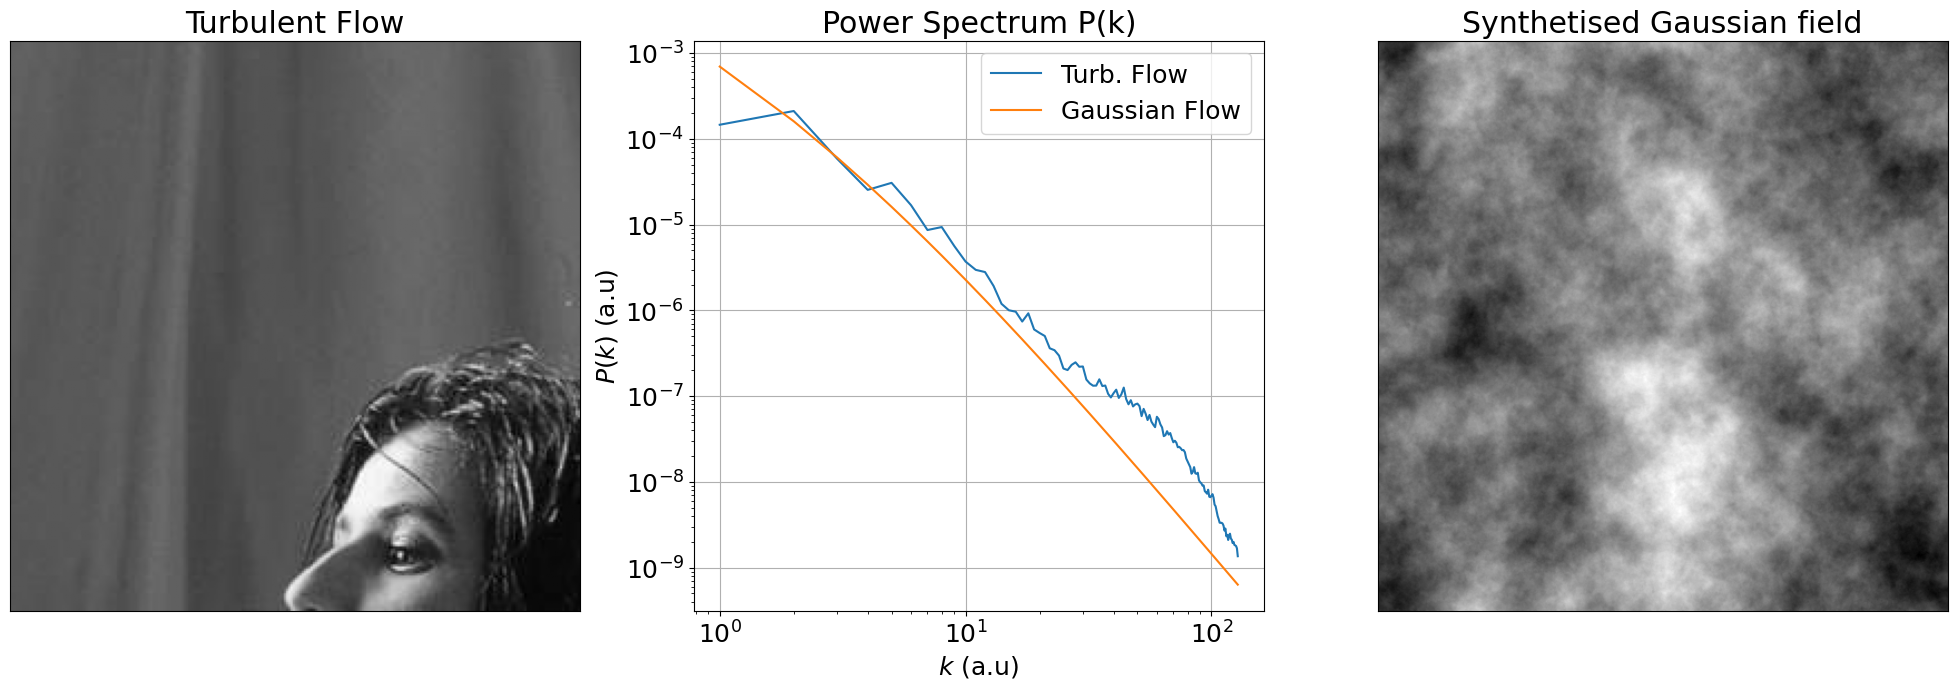

In [86]:
fig, axs = plt.subplots(1,3,figsize=(25,10))

axs[0].imshow(image,cmap='gray')
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title("Turbulent Flow")

# plotting the power spectrum in log log
# x = kvals, y = Abins = 1D radially averaged spectrum
axs[1].loglog(kvals, Abins,label='Turb. Flow')
axs[1].loglog(kvals,10**pk_interp(np.log10(kvals)), label='Gaussian Flow')
axs[1].set_xlabel("$k$ (a.u)")
axs[1].set_ylabel("$P(k)$ (a.u)")
dy=np.abs(np.log10(axs[1].get_ylim()[1])-np.log10(axs[1].get_ylim()[0]))
dx=np.abs(np.log10(axs[1].get_xlim()[1])-np.log10(axs[1].get_xlim()[0]))
golden_mean = 1#(np.sqrt(5)-1.0)/2.0
axs[1].set_aspect((dx/dy)*golden_mean,adjustable='box')
axs[1].legend()

axs[1].set_title("Power Spectrum P(k)")
axs[1].grid()

axs[2].imshow(lnpb.delta_x(),cmap='gray')
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title("Synthetised Gaussian field")
plt.show()

# Conclusion

The gaussian field with the same power spectrum as the turbulent flow, does not respect the geometry of the structures.